In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
# 1. Set path
data_dir = r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data"  # Replace this with your actual path

In [3]:
# 2. Parameters
img_size = (128, 128)  # Resize all images to 128x128
batch_size = 32

In [4]:
# 3. Data preprocessing using ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80% training, 20% validation
)


In [5]:
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)


Found 1592 images belonging to 15 classes.


In [6]:
val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 391 images belonging to 15 classes.


In [7]:
# 4. Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])


In [8]:
# 5. Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

model.fit(train_generator, validation_data=val_generator, epochs=30, class_weight=class_weights)


Epoch 1/30
50/50 [==============================] - 32s 593ms/step - loss: 2.6538 - accuracy: 0.1124 - val_loss: 2.4823 - val_accuracy: 0.2097
Epoch 2/30
50/50 [==============================] - 28s 561ms/step - loss: 2.3590 - accuracy: 0.2500 - val_loss: 2.1913 - val_accuracy: 0.3069
Epoch 3/30
50/50 [==============================] - 28s 554ms/step - loss: 2.0322 - accuracy: 0.3618 - val_loss: 2.1255 - val_accuracy: 0.2839
Epoch 4/30
50/50 [==============================] - 28s 552ms/step - loss: 1.6530 - accuracy: 0.4887 - val_loss: 2.1489 - val_accuracy: 0.3504
Epoch 5/30
50/50 [==============================] - 28s 555ms/step - loss: 1.4002 - accuracy: 0.5697 - val_loss: 1.9656 - val_accuracy: 0.4066
Epoch 6/30
50/50 [==============================] - 28s 553ms/step - loss: 1.0084 - accuracy: 0.7029 - val_loss: 2.2556 - val_accuracy: 0.3913
Epoch 7/30
50/50 [==============================] - 28s 556ms/step - loss: 0.7755 - accuracy: 0.7726 - val_loss: 2.6003 - val_accuracy: 0.3811

In [10]:
# 7. Save the model
model.save("animal_cnn_model.h5")

C:\Users\ASUS\.android\annaconda\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/10
50/50 [==============================] - 32s 591ms/step - loss: 0.0700 - accuracy: 0.9830 - val_loss: 4.9724 - val_accuracy: 0.4015
Epoch 2/10
50/50 [==============================] - 29s 573ms/step - loss: 0.0646 - accuracy: 0.9805 - val_loss: 5.0972 - val_accuracy: 0.4066
Epoch 3/10
50/50 [==============================] - 29s 581ms/step - loss: 0.0637 - accuracy: 0.9793 - val_loss: 5.0152 - val_accuracy: 0.4194
Epoch 4/10
50/50 [==============================] - 28s 561ms/step - loss: 0.0880 - accuracy: 0.9749 - val_loss: 4.9447 - val_accuracy: 0.4118
Epoch 5/10
50/50 [==============================] - 28s 551ms/step - loss: 0.0668 - accuracy: 0.9837 - val_loss: 5.3323 - val_accuracy: 0.3913
Epoch 6/10
50/50 [==============================] - 30s 598ms/step - loss: 0.0865 - accuracy: 0.9805 - val_loss: 5.5426 - val_accuracy: 0.4041
Epoch 7/10
50/50 [==============================] - 29s 573ms/step - loss: 0.0537 - accuracy: 0.9856 - val_loss: 6.4270 - val_accuracy: 0.3785

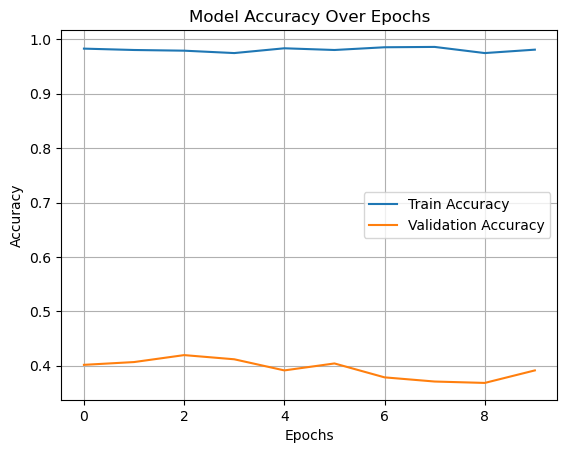

In [28]:
# This line trains your model and stores the history
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

import matplotlib.pyplot as plt

# Plot accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


In [30]:
from tensorflow.keras.models import load_model


# Only run this ONCE at the beginning
model = load_model("animal_cnn_model.h5")

# Then run prediction on different images like this
def predict_image(image_path):
    img = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)

    class_labels = ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse',
                    'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']
    predicted_label = class_labels[predicted_class]

    # Show result
    plt.imshow(img)
    plt.title(f"Predicted class: {predicted_label}")
    plt.axis('off')
    plt.show()


1/1 [==============================] - 0s 263ms/step


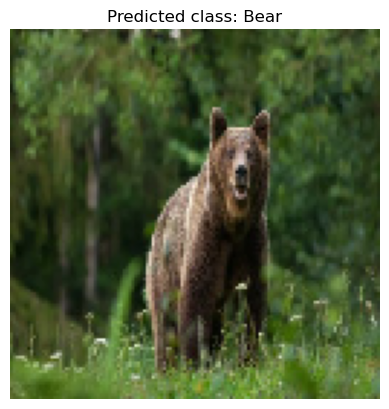

In [32]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Bear_3.jpg")

1/1 [==============================] - 0s 38ms/step


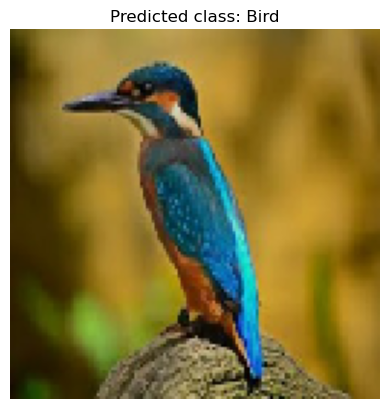

In [34]:
predict_image(r'C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Bird_1_2.jpg')

1/1 [==============================] - 0s 49ms/step


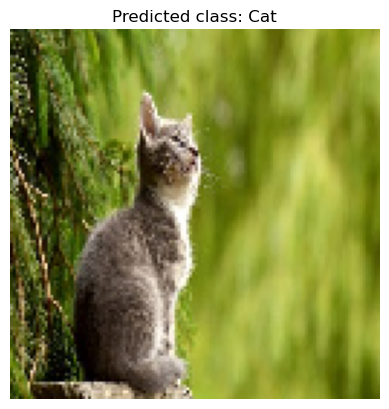

In [36]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Cat_15_2.jpg")

1/1 [==============================] - 0s 64ms/step


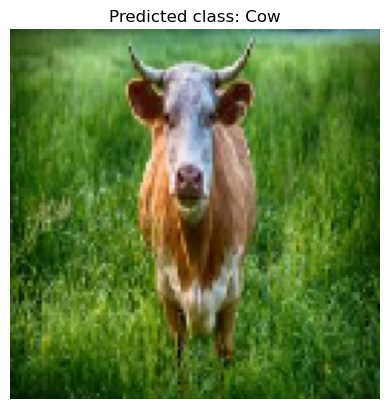

In [38]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Cow\Cow_4_1.jpg")

1/1 [==============================] - 0s 65ms/step


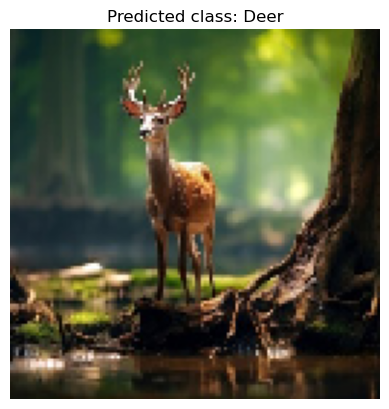

In [40]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Deer\Deer_23_1.jpg")

1/1 [==============================] - 0s 54ms/step


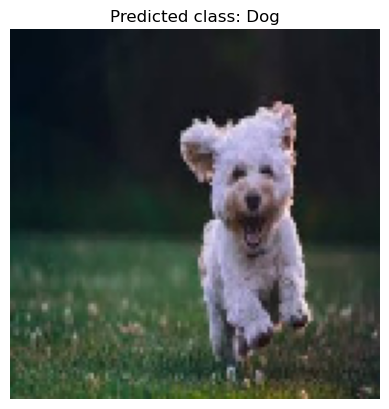

In [42]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Dog\Dog_24.jpeg")


1/1 [==============================] - 0s 50ms/step


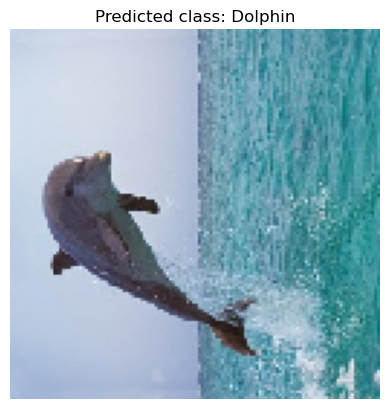

In [44]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Dolphin\Dolphin_2_3.jpg")


1/1 [==============================] - 0s 42ms/step


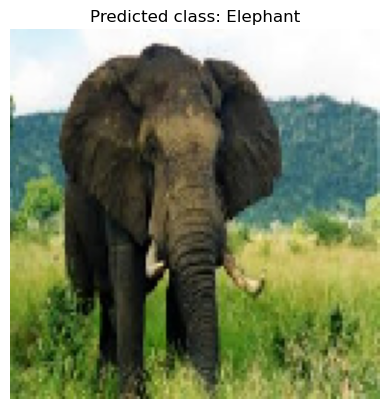

In [46]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Elephant\Elephant_1_1 - Copy.jpg")


1/1 [==============================] - 0s 56ms/step


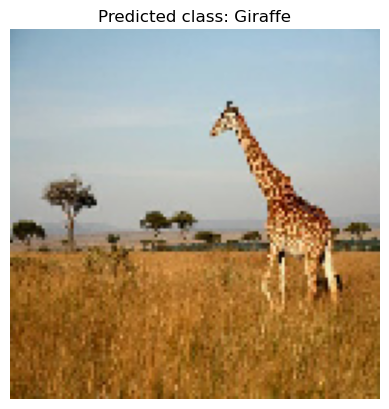

In [48]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Giraffe\Giraffe_4_1.jpg")


1/1 [==============================] - 0s 45ms/step


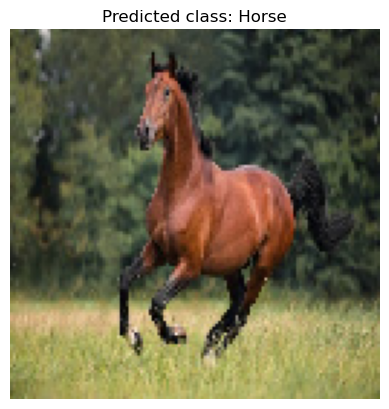

In [50]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Horse\Horse_3_1.jpg")


1/1 [==============================] - 0s 52ms/step


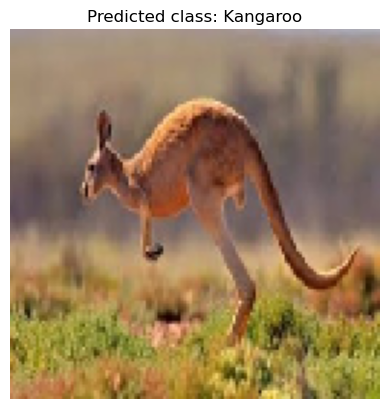

In [52]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Kangaroo\Kangaroo_4_1.jpg")

1/1 [==============================] - 0s 63ms/step


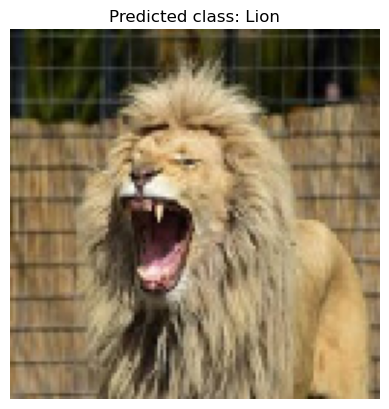

In [54]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Lion\Lion_21.jpeg")


1/1 [==============================] - 0s 45ms/step


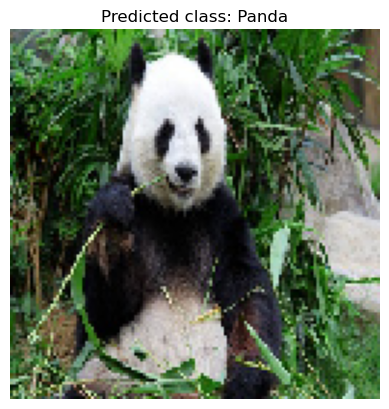

In [56]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Panda\Panda_4.jpg")


1/1 [==============================] - 0s 46ms/step


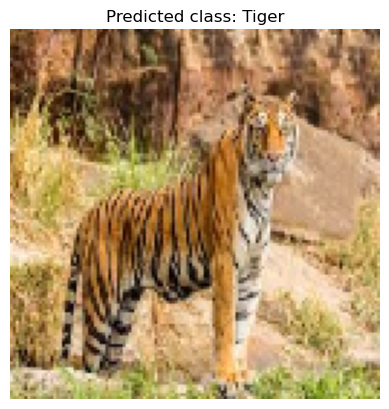

In [58]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Tiger\Tiger_9_2.jpg")

1/1 [==============================] - 0s 48ms/step


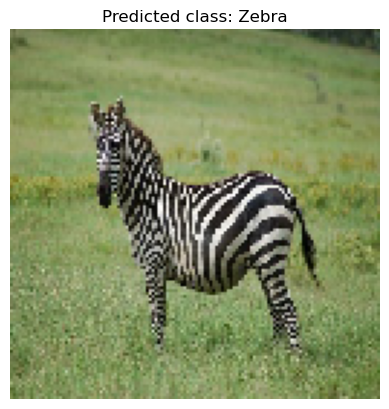

In [60]:
predict_image(r"C:\Users\ASUS\Desktop\ML_Project(SMP)\Animal_data\Animal_data\Zebra\Zebra_6_2.jpg")



1/1 [==============================] - 0s 63ms/step


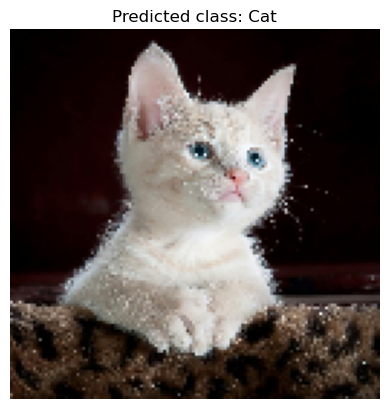

In [62]:
predict_image(r"C:\Users\ASUS\Downloads\pexels-pixabay-45201.jpg")

1/1 [==============================] - 0s 44ms/step


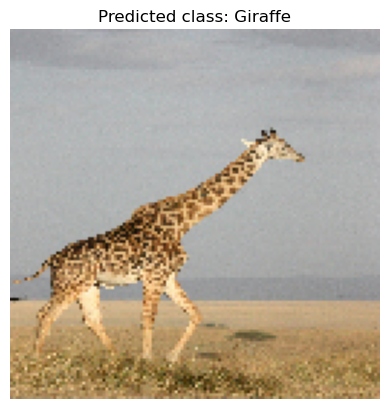

In [64]:
predict_image(r"C:\Users\ASUS\Downloads\pexels-pixabay-67552.jpg")


1/1 [==============================] - 0s 66ms/step

Accuracy: 0.36

Classification Report:
              precision    recall  f1-score   support

        Bear       0.10      0.20      0.14        25
        Bird       0.40      0.15      0.22        27
         Cat       0.22      0.17      0.19        24
         Cow       0.14      0.27      0.19        26
        Deer       0.13      0.08      0.10        25
         Dog       0.10      0.08      0.09        24
     Dolphin       0.83      1.00      0.91        25
    Elephant       0.67      0.12      0.20        34
     Giraffe       0.46      0.72      0.56        25
       Horse       0.28      0.27      0.27        26
    Kangaroo       0.27      0.12      0.17        25
        Lion       0.35      0.35      0.35        26
       Panda       0.65      0.81      0.72        27
       Tiger       0.52      0.44      0.48        25
       Zebra       0.50      0.70      0.58        27

    accuracy                           0.3

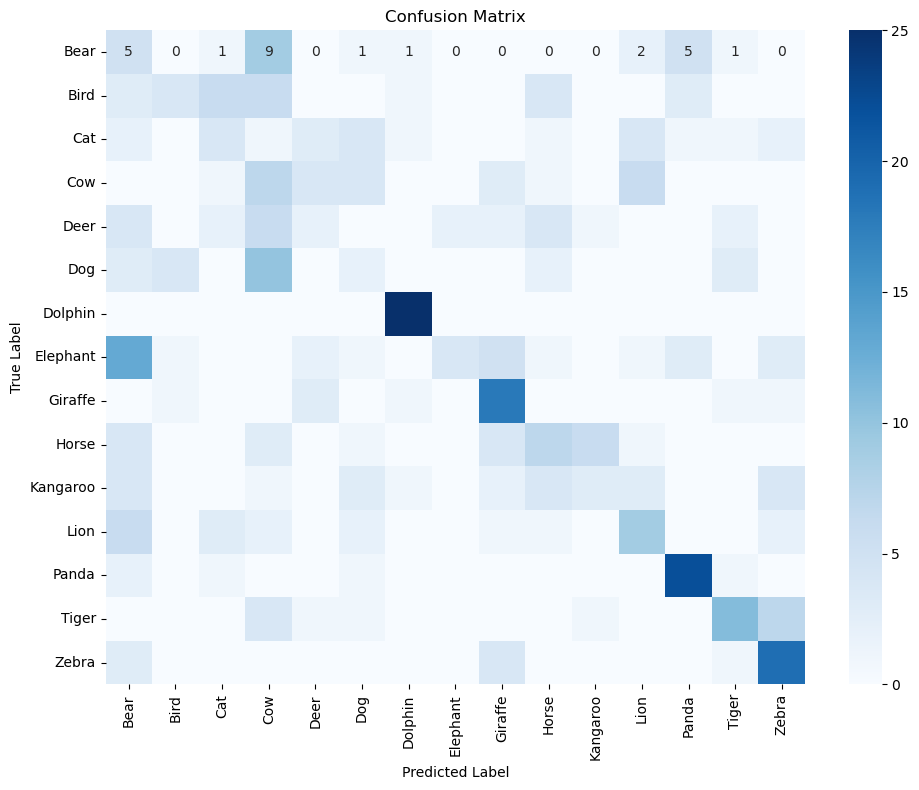

In [66]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Get all predictions and true labels from validation set
y_true = []
y_pred = []

# Loop through the validation generator
val_generator.reset()
for i in range(len(val_generator)):
    x_batch, y_batch = val_generator[i]
    preds = model.predict(x_batch)
    
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Class labels
class_labels = list(val_generator.class_indices.keys())

# ✅ Accuracy Score
acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {acc:.2f}")

# ✅ Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# ✅ Plot confusion matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
